# Detecting expr2.fsize plot (0614 TA-only)

Run this notebook on af309 with the `xfold-scripts` kernel. Set `RUN_ROOTS` to one or more host data directories; all roots are plotted in one figure.


In [85]:
from pathlib import Path
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FuncFormatter

# Set one shuffle at a time; do not aggregate shuffle0/1/2 in one plot.
# Host order is gnr, amd, c920bn3.
RUN_ROOTS_SHUFFLE0 = [
    Path('/astrum/home/hpchzy/code/data/20260615/cgnr6760pn2/outputDetecting/expr2fsize/walk20/20260615-094403/detecting.expr2.fsize.shuffle0/'),
    Path('/astrum/home/hpchzy/code/data/20260615/camd9554n1/outputDetecting/expr2fsize/walk20/20260615-094401/detecting.expr2.fsize.shuffle0/'),
    Path('/astrum/home/hpchzy/code/data/20260615/c920bn3/outputDetecting/expr2fsize/walk20/20260615-094204/detecting.expr2.fsize.shuffle0/'),
]
RUN_ROOTS_SHUFFLE1 = [
    Path('/astrum/home/hpchzy/code/data/20260615/cgnr6760pn2/outputDetecting/expr2fsize/walk20/20260615-094403/detecting.expr2.fsize.shuffle1/'),
    Path('/astrum/home/hpchzy/code/data/20260615/camd9554n1/outputDetecting/expr2fsize/walk20/20260615-094401/detecting.expr2.fsize.shuffle1/'),
    Path('/astrum/home/hpchzy/code/data/20260615/c920bn3/outputDetecting/expr2fsize/walk20/20260615-094204/detecting.expr2.fsize.shuffle1/'),
]
RUN_ROOTS_SHUFFLE2 = [
    Path('/astrum/home/hpchzy/code/data/20260615/cgnr6760pn2/outputDetecting/expr2fsize/walk20/20260615-094403/detecting.expr2.fsize.shuffle2/'),
    Path('/astrum/home/hpchzy/code/data/20260615/camd9554n1/outputDetecting/expr2fsize/walk20/20260615-094401/detecting.expr2.fsize.shuffle2/'),
    Path('/astrum/home/hpchzy/code/data/20260615/c920bn3/outputDetecting/expr2fsize/walk20/20260615-094204/detecting.expr2.fsize.shuffle2/'),
]
RUN_ROOTS = RUN_ROOTS_SHUFFLE1

def host_from_root(root):
    parts = list(root.parts)
    if '20260615' in parts:
        idx = parts.index('20260615')
        if idx + 1 < len(parts):
            return parts[idx + 1]
    return parts[-6] if len(parts) >= 6 else root.name

HOST_ORDER = [host_from_root(root) for root in RUN_ROOTS]

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "scripts":
    REPO_ROOT = REPO_ROOT.parent
OUT_DIR = REPO_ROOT / "scripts_plot/outputDetecting"
OUT_DIR.mkdir(parents=True, exist_ok=True)

RL_QUANTILE_BOUNDARY = [0.0, 0.9]
RH_QUANTILE_BOUNDARY = [0.9, 0.995]
Y_LIMIT_MAX = 100

TIMER_COLORS = {
    "tsc": "tab:blue",
    "tsc_asym": "tab:cyan",
    "clock_gettime": "tab:orange",
    "mpi_wtime": "tab:green",
    "papi": "tab:red",
    "papix6": "tab:purple",
    "likwid": "tab:brown",
    "cntvct": "tab:cyan",
    "cntvct_fence": "tab:olive",
    "cntvcto": "tab:pink",
}

RUN_TAG = f"multi_host_{RUN_ROOTS[0].name}" if len(RUN_ROOTS) > 1 else RUN_ROOTS[0].name

for root in RUN_ROOTS:
    print(root)
print("host_order:", HOST_ORDER)


/astrum/home/hpchzy/code/data/20260615/cgnr6760pn2/outputDetecting/expr2fsize/walk20/20260615-094403/detecting.expr2.fsize.shuffle1
/astrum/home/hpchzy/code/data/20260615/camd9554n1/outputDetecting/expr2fsize/walk20/20260615-094401/detecting.expr2.fsize.shuffle1
/astrum/home/hpchzy/code/data/20260615/c920bn3/outputDetecting/expr2fsize/walk20/20260615-094204/detecting.expr2.fsize.shuffle1
host_order: ['cgnr6760pn2', 'camd9554n1', 'c920bn3']


In [86]:
def parse_meta(path):
    d = {}
    if not path.exists():
        return d
    for line in path.read_text(errors="ignore").splitlines():
        if "=" in line:
            k, v = line.split("=", 1)
            d[k.strip()] = v.strip()
    return d


def read_values(path):
    vals = []
    for line in path.read_text(errors="ignore").splitlines():
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        try:
            vals.append(float(line.split(",")[-1]))
        except ValueError:
            pass
    return vals


def q(vals, p):
    vals = sorted(vals)
    if not vals:
        return math.nan
    if len(vals) == 1:
        return vals[0]
    pos = p * (len(vals) - 1)
    lo, hi = math.floor(pos), math.ceil(pos)
    if lo == hi:
        return vals[lo]
    return vals[lo] * (hi - pos) + vals[hi] * (pos - lo)




def local_w_hat(theory, measured, x_idx, y_idx):
    theory, measured = sorted(theory), sorted(measured)
    if not theory or not measured or x_idx > y_idx:
        return math.nan
    tau = measured[0] - theory[0]
    vals = []
    for idx in range(x_idx, y_idx + 1):
        p = (idx - 1) / (RL_RH_NQUANT - 1)
        vals.append(abs(q(measured, p) - q(theory, p) - tau))
    return float(np.mean(vals)) if vals else math.nan


def base_w_hat(vals, x_idx, y_idx):
    vals = sorted(vals)
    if not vals or x_idx > y_idx:
        return math.nan
    vmin = vals[0]
    out = []
    for idx in range(x_idx, y_idx + 1):
        p = (idx - 1) / (RL_RH_NQUANT - 1)
        out.append(abs(q(vals, p) - vmin))
    return float(np.mean(out)) if out else math.nan


def rl_rh_detail(measured, theory):
    low_num = local_w_hat(theory, measured, 1, RL_RH_Q)
    high_num = local_w_hat(theory, measured, RL_RH_Q + 1, RL_RH_NQUANT - RL_RH_DELTA)
    low_den = base_w_hat(measured, 1, RL_RH_Q)
    high_den = base_w_hat(measured, RL_RH_Q + 1, RL_RH_NQUANT - RL_RH_DELTA)
    eps = 1e-9
    rl = low_num / low_den * 100 if low_den and low_den > eps and np.isfinite(low_den) else math.nan
    rh = high_num / high_den * 100 if high_den and high_den > eps and np.isfinite(high_den) else math.nan
    return rl, rh, low_num, low_den, high_num, high_den



def drop_top_pair(measured, theory, frac):
    if frac <= 0 or not measured:
        return list(measured), list(theory)
    pairs = sorted(zip(measured, theory), key=lambda x: x[0])
    keep = max(1, int(math.floor(len(pairs) * (1.0 - frac))))
    pairs = pairs[:keep]
    return [m for m, _ in pairs], [t for _, t in pairs]

def ta_from_run_dir(run_dir, meta):
    m = re.search(r"_ta([0-9.]+)", run_dir.name)
    if m:
        return float(m.group(1))
    return float(meta.get("mu_ns", meta.get("interval_ns", 0)) or 0)


In [87]:
rows = []
for run_root in RUN_ROOTS:
    for cdf in sorted(run_root.rglob("*_ta_cdf.csv")):
        run_dir = cdf.parent
        combo_dir = run_dir.parent
        meta = parse_meta(run_dir / "meta.txt") or parse_meta(combo_dir / "meta.txt")
        measured = read_values(cdf)
        if not measured:
            continue
        ta = ta_from_run_dir(run_dir, meta)
        rows.append({
            "host": meta.get("host", run_root.parts[-5] if len(run_root.parts) >= 5 else ""),
            "expr": meta.get("expr_name", run_root.name),
            "np": int(meta.get("np", 0) or 0),
            "timer": meta.get("timer", cdf.parents[2].name),
            "interval_ns": int(float(meta.get("interval_ns", meta.get("mu_ns", 0)) or 0)),
            "fsize_kib": int(float(meta.get("fsize_kib", 0) or 0)),
            "fkern": meta.get("fkern", ""),
            "rkern": meta.get("rkern", ""),
            "ta": ta,
            "n_measured": len(measured),
            "measured": measured,
            "theory": [ta] * len(measured),
            "run_dir": str(run_dir),
            "run_root": str(run_root),
        })

raw = pd.DataFrame(rows)
print(f"roots: {len(RUN_ROOTS)}, cdf files: {len(raw)}")
raw.head()


roots: 3, cdf files: 4180


,host,expr,np,timer,interval_ns,fsize_kib,fkern,rkern,ta,n_measured,measured,theory,run_dir,run_root
0,cgnr6760pn2,detecting.expr2.fsize,64,clock_gettime,1000,0,copy,none,1000.0,100,"[1034.0, 1036.0, 1036.0, 1036.0, 1038.0, 1039....","[1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000....",/astrum/home/hpchzy/code/data/20260615/cgnr676...,/astrum/home/hpchzy/code/data/20260615/cgnr676...
1,cgnr6760pn2,detecting.expr2.fsize,64,clock_gettime,1000,0,copy,none,998.0,100,"[1032.0, 1033.0, 1034.0, 1034.0, 1035.0, 1035....","[998.0, 998.0, 998.0, 998.0, 998.0, 998.0, 998...",/astrum/home/hpchzy/code/data/20260615/cgnr676...,/astrum/home/hpchzy/code/data/20260615/cgnr676...
2,cgnr6760pn2,detecting.expr2.fsize,64,clock_gettime,1000,0,copy,none,1001.0,100,"[1036.0, 1037.0, 1039.0, 1039.0, 1039.0, 1039....","[1001.0, 1001.0, 1001.0, 1001.0, 1001.0, 1001....",/astrum/home/hpchzy/code/data/20260615/cgnr676...,/astrum/home/hpchzy/code/data/20260615/cgnr676...
3,cgnr6760pn2,detecting.expr2.fsize,64,clock_gettime,1000,0,copy,none,1001.0,100,"[1036.0, 1038.0, 1038.0, 1039.0, 1039.0, 1040....","[1001.0, 1001.0, 1001.0, 1001.0, 1001.0, 1001....",/astrum/home/hpchzy/code/data/20260615/cgnr676...,/astrum/home/hpchzy/code/data/20260615/cgnr676...
4,cgnr6760pn2,detecting.expr2.fsize,64,clock_gettime,1000,0,copy,none,997.0,100,"[1031.0, 1032.0, 1033.0, 1033.0, 1034.0, 1034....","[997.0, 997.0, 997.0, 997.0, 997.0, 997.0, 997...",/astrum/home/hpchzy/code/data/20260615/cgnr676...,/astrum/home/hpchzy/code/data/20260615/cgnr676...


In [88]:
def wasserstein_distance(u_values, v_values):
    import numpy as _np
    u = _np.sort(_np.asarray(u_values, dtype=float))
    v = _np.sort(_np.asarray(v_values, dtype=float))
    if u.size == 0 or v.size == 0:
        return float('nan')
    all_values = _np.concatenate((u, v))
    all_values.sort()
    deltas = _np.diff(all_values)
    if deltas.size == 0:
        return 0.0
    u_cdf = _np.searchsorted(u, all_values[:-1], side='right') / u.size
    v_cdf = _np.searchsorted(v, all_values[:-1], side='right') / v.size
    return float(_np.sum(_np.abs(u_cdf - v_cdf) * deltas))
import numpy as np

RL_QUANTILE_BOUNDARY = [0.0, 0.9]
RH_QUANTILE_BOUNDARY = [0.9, 0.995]


def quantile_window(values, lo, hi):
    lb = np.quantile(values, lo)
    ub = np.quantile(values, hi)
    return values[(values >= lb) & (values <= ub)], lb, ub


def spread_wasserstein(values):
    return wasserstein_distance(values, np.zeros_like(values))


summary_rows = []
keys = ["host", "expr", "np", "timer", "fsize_kib", "fkern", "rkern"]
for key, g in raw.groupby(keys, dropna=False):
    measured_raw = np.array([x for vals in g["measured"] for x in vals], dtype=float)
    theory_raw = np.array([x for vals in g["theory"] for x in vals], dtype=float)

    measured_aligned = measured_raw - np.min(measured_raw)
    theory_aligned = theory_raw - np.min(theory_raw)

    measured_rl, measured_rl_lb_q, measured_rl_ub_q = quantile_window(measured_aligned, *RL_QUANTILE_BOUNDARY)
    theory_rl, theory_rl_lb_q, theory_rl_ub_q = quantile_window(theory_aligned, *RL_QUANTILE_BOUNDARY)
    measured_rl_w = spread_wasserstein(measured_rl)
    theory_rl_w = spread_wasserstein(theory_rl)
    rl = measured_rl_w / theory_rl_w if theory_rl_w else math.nan

    measured_rh, measured_rh_lb_q, measured_rh_ub_q = quantile_window(measured_aligned, *RH_QUANTILE_BOUNDARY)
    theory_rh, theory_rh_lb_q, theory_rh_ub_q = quantile_window(theory_aligned, *RH_QUANTILE_BOUNDARY)
    measured_rh_w = spread_wasserstein(measured_rh)
    theory_rh_w = spread_wasserstein(theory_rh)
    rh = measured_rh_w / theory_rh_w if theory_rh_w else math.nan

    row = dict(zip(keys, key))
    row.update({
        "rl": rl,
        "rl_numerator": measured_rl_w,
        "rl_denominator": theory_rl_w,
        "rh": rh,
        "rh_numerator": measured_rh_w,
        "rh_denominator": theory_rh_w,
        "measured_rl_w": measured_rl_w,
        "theory_rl_w": theory_rl_w,
        "measured_rh_w": measured_rh_w,
        "theory_rh_w": theory_rh_w,
        "measured_q5": np.quantile(measured_aligned, 0.05),
        "measured_q25": np.quantile(measured_aligned, 0.25),
        "measured_q50": np.quantile(measured_aligned, 0.5),
        "measured_q75": np.quantile(measured_aligned, 0.75),
        "measured_q95": np.quantile(measured_aligned, 0.95),
        "theory_q50": np.quantile(theory_aligned, 0.50),
        "measured_rl_lb_q": measured_rl_lb_q,
        "measured_rl_ub_q": measured_rl_ub_q,
        "theory_rl_lb_q": theory_rl_lb_q,
        "theory_rl_ub_q": theory_rl_ub_q,
        "measured_rh_lb_q": measured_rh_lb_q,
        "measured_rh_ub_q": measured_rh_ub_q,
        "theory_rh_lb_q": theory_rh_lb_q,
        "theory_rh_ub_q": theory_rh_ub_q,
    })
    summary_rows.append(row)
df = pd.DataFrame(summary_rows)
host_rank = {host: idx for idx, host in enumerate(HOST_ORDER)}
df["host_order"] = df["host"].map(host_rank).fillna(len(host_rank)).astype(int)
df = df.sort_values(["host_order", "np", "timer", "fsize_kib"]).reset_index(drop=True)
df = df[(df['timer'] != 'cntvct_fence') & (df['timer'] != 'tsc_asym') & (df['fsize_kib'] > 0)]
mapping = {
    "cgnr6760pn2": "Intel Xeon 6760P",
    "camd9554n2": "AMD EPYC 9554",
    "camd9554n1": "AMD EPYC 9554",
    "c920bn3": "Kunpeng 920B",
}

df['hostname']=df['host'].map(mapping).fillna(df['host'])
# df.to_csv("demo.0602.csv", index=False)
df.head()


,host,expr,np,timer,fsize_kib,fkern,rkern,rl,rl_numerator,rl_denominator,...,measured_rl_lb_q,measured_rl_ub_q,theory_rl_lb_q,theory_rl_ub_q,measured_rh_lb_q,measured_rh_ub_q,theory_rh_lb_q,theory_rh_ub_q,host_order,hostname
1,cgnr6760pn2,detecting.expr2.fsize,64,clock_gettime,16,copy,none,4.271091,12.138889,2.842105,...,0.0,63.1,0.0,4.0,63.1,5305.005,4.0,5.0,0,Intel Xeon 6760P
2,cgnr6760pn2,detecting.expr2.fsize,64,clock_gettime,32,copy,none,4.308621,12.245556,2.842105,...,0.0,62.1,0.0,4.0,62.1,158.035,4.0,5.0,0,Intel Xeon 6760P
3,cgnr6760pn2,detecting.expr2.fsize,64,clock_gettime,64,copy,none,4.340093,12.335000,2.842105,...,0.0,59.2,0.0,4.0,59.2,154.000,4.0,5.0,0,Intel Xeon 6760P
4,cgnr6760pn2,detecting.expr2.fsize,64,clock_gettime,128,copy,none,4.182217,11.886301,2.842105,...,0.0,61.0,0.0,4.0,61.0,144.010,4.0,5.0,0,Intel Xeon 6760P
5,cgnr6760pn2,detecting.expr2.fsize,64,clock_gettime,256,copy,none,3.906904,11.103831,2.842105,...,0.0,61.0,0.0,4.0,61.0,209.540,4.0,5.0,0,Intel Xeon 6760P


saved: /astrum/home/hpchzy/code/TacVar/scripts_plot/outputDetecting/detecting_expr2_fsize_0614_multi_host_detecting.expr2.fsize.shuffle1.png


/tmp/ipykernel_1501128/1930700217.py:39: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


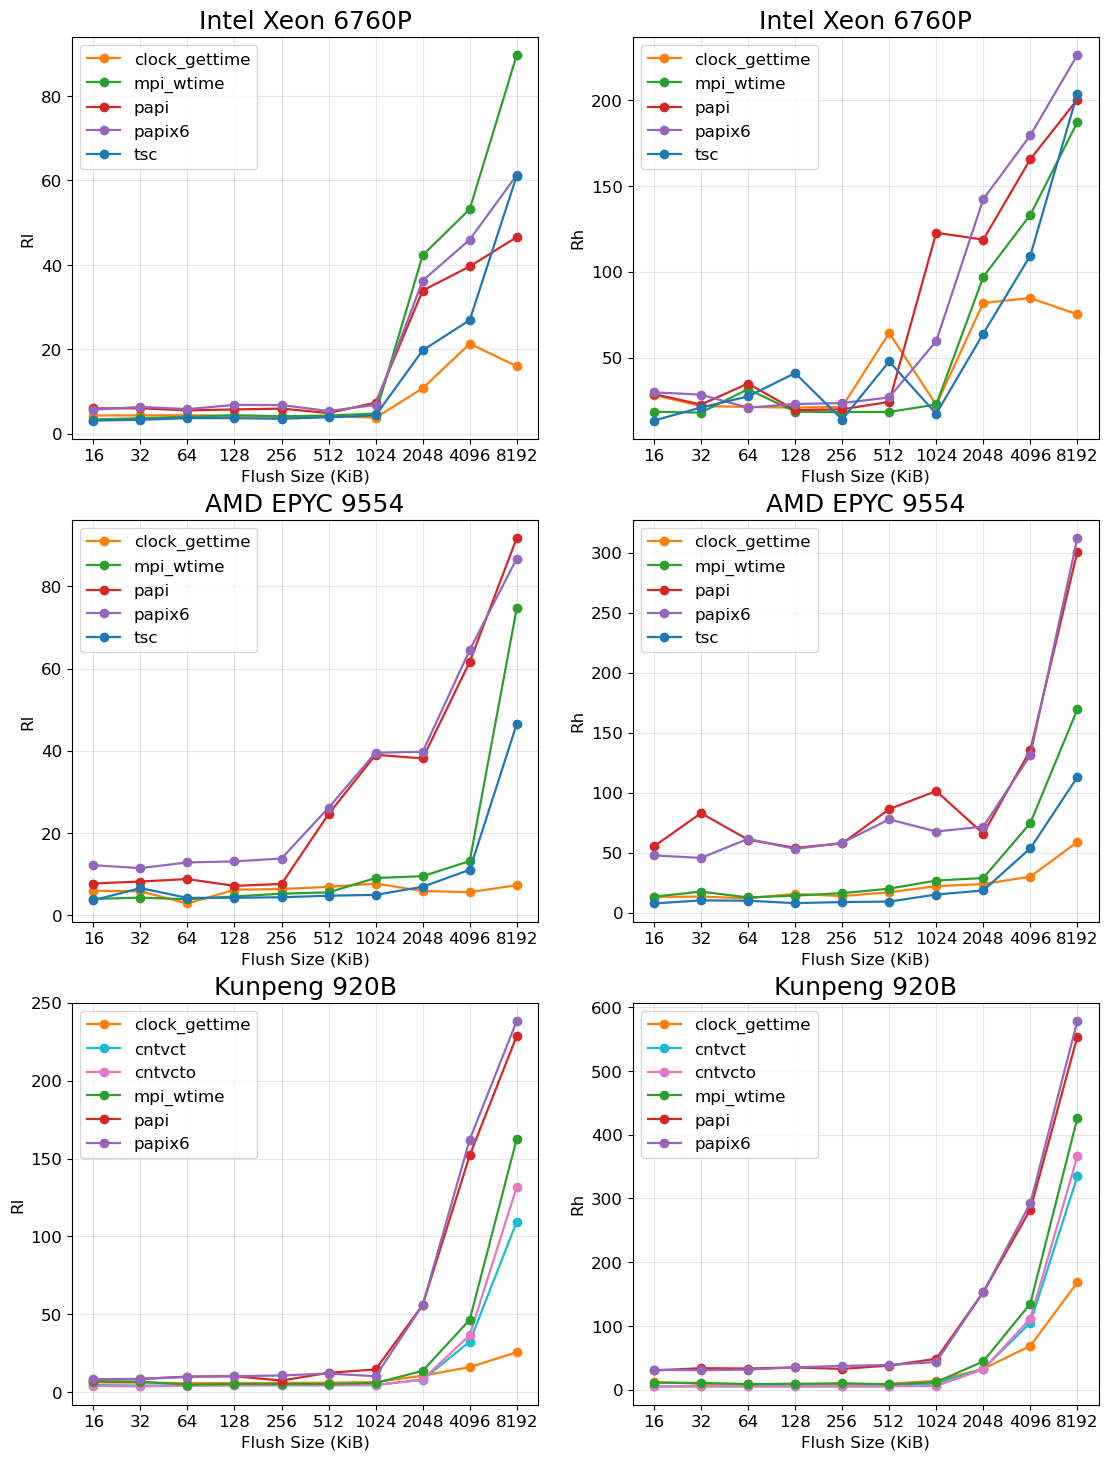

In [ ]:
plot_df = df.copy()
plot_df = plot_df[plot_df["timer"]!="cntvct"]



metrics = [("rl", "Rl"), ("rh", "Rh")]
hosts = [host for host in HOST_ORDER if host in set(plot_df["host"].dropna())]
nrows = max(1, len(hosts))
fig, axes = plt.subplots(nrows, 2, figsize=(13.5, 6 * nrows), squeeze=False, constrained_layout=True)

fsize_ticks = sorted(int(x) for x in plot_df["fsize_kib"].dropna().unique())
for row_idx, host in enumerate(hosts):
    host_df = plot_df[plot_df["host"] == host]
    for col_idx, (metric, ylabel) in enumerate(metrics):
        ax = axes[row_idx][col_idx]
        for timer, g in host_df.groupby("timer"):
            g = g.sort_values("fsize_kib")
            color = TIMER_COLORS.get(timer, None)
            ax.plot(g["fsize_kib"], g[metric], marker="o", linewidth=1.6, label=timer, color=color)

        ax.set_xscale("log", base=2)
        ax.xaxis.set_major_locator(FixedLocator(fsize_ticks))
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x)}" if int(x) in fsize_ticks else ""))
        ax.set_xlabel("Flush Size (KiB)", fontsize=12)
        ax.set_ylabel(ylabel, fontsize=12)
        # ax.set_ylim(0, Y_LIMIT_MAX)
        ax.set_title(f"{mapping.get(host, host)}", fontsize=18)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=12)
        ax.tick_params(axis='both', labelsize=12)

if plot_df.empty:
    pass
else:
    expr = plot_df["expr"].iloc[0]
    np_val = plot_df["np"].iloc[0]

# fig.text(0.5, -0.02, " | ".join(str(p) for p in RUN_ROOTS), ha="center", va="bottom", fontsize=8)
FIG_PATH = OUT_DIR / f"detecting_expr2_fsize_0614_{RUN_TAG}.png"
fig.savefig(FIG_PATH, dpi=220, bbox_inches="tight")
print(f"saved: {FIG_PATH}")

fig.tight_layout()
plt.show()
